# Notebook Retraining Final

Melatih ulang model terbaik per task menggunakan **semua data train**.

**Skenario Terbaik per Task:**
| Task | Skenario | Arsitektur | Embedding | Teks |
|------|----------|-----------|-----------|------|
| Task 1 Aspek    | Sk8 BiLSTM_FT_Stem       | BiLSTM | FastText | Stem    |
| Task 2 Room     | Sk4 CNN_FT_Stem           | CNN    | FastText | Stem    |
| Task 3 Hotel    | Sk5 BiLSTM_W2V_NonStem   | BiLSTM | Word2Vec | NonStem |
| Task 4 Location | Sk1 CNN_W2V_NonStem       | CNN    | Word2Vec | NonStem |
| Task 5 Service  | Sk2 CNN_W2V_Stem          | CNN    | Word2Vec | Stem    |

**Perbedaan dengan training K-Fold:**
| Aspek | Training K-Fold | Retraining Final |
|-------|----------------|------------------|
| Data | 80% train, 20% val | 100% train |
| Tujuan | Evaluasi performa | Buat model deployment |
| Early stopping | monitor `val_loss` | monitor `loss` |
| Output | Metrik per fold | Model `.h5` final |


## 1. Instalasi dan Import Library


In [ ]:
# Install library yang diperlukan
!pip install gensim scikit-learn openpyxl tensorflow --quiet

# Import semua library
import os, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Concatenate, Dense, Dropout,
    Bidirectional, LSTM
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec
from google.colab import drive

drive.mount('/content/drive')
print(f'TensorFlow: {tf.__version__}')
print('Import selesai.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.4 MB/s eta 0:00:00
Mounted at /content/drive
TensorFlow: 2.19.0
Import selesai.


## 2. Konfigurasi Path dan Hyperparameter


In [ ]:
# ── Path folder ──
BASE_DIR  = '/content/drive/MyDrive/SKRIPSI_NAVY/'
SPLIT_DIR = BASE_DIR + 'Dataset/Dataset_Persiapan/Dataset_SplitData/'
TOKEN_DIR = BASE_DIR + 'Dataset/Dataset_Persiapan/Dataset_Tokenizer/'
EMBED_DIR = BASE_DIR + 'Dataset/Dataset_Persiapan/Dataset_WordEmbedding/'
FINAL_DIR = BASE_DIR + 'Dataset/Model_Final_Fix20/'
os.makedirs(FINAL_DIR, exist_ok=True)

# ── Hyperparameter ──
# Sama dengan saat training K-Fold
MAX_LENGTH = 100   # panjang maksimum token per ulasan
MAX_EPOCH  = 20    # sama dengan training K-Fold
BATCH_SIZE = 32    # jumlah data per batch
LR         = 0.001 # learning rate Adam optimizer
L2_STR     = 0.001 # kekuatan regularisasi L2
PATIENCE   = 3     # sama dengan training K-Fold

# ── Konfigurasi skenario terbaik per task ──
# text_col = kolom teks yang digunakan model
# label_cols = kolom target yang diprediksi
# ── Skenario Terbaik per Task ──
# Task 1: Sk8 BiLSTM + FastText + Stem
# Task 2: Sk4 CNN    + FastText + Stem
# Task 3: Sk5 BiLSTM + Word2Vec + NonStem
# Task 4: Sk1 CNN    + Word2Vec + NonStem
# Task 5: Sk2 CNN    + Word2Vec + Stem
TASKS = {
    'Task1_Aspek': {
        'skenario'   : 'Skenario8_BiLSTM_FT_Stem',
        'arsitektur' : 'bilstm',
        'train_file' : SPLIT_DIR + 'df_train_full.csv',
        'token_file' : TOKEN_DIR + 'tokenizer_stem.pkl',
        'embed_file' : EMBED_DIR + 'fasttext_stemmed.model',
        'text_col'   : 'review_stemmed',
        'label_cols' : ['Room_label','Hotel_label',
                        'Location_label','Service_label'],
        'output_dir' : FINAL_DIR + 'Task1_Aspek/',
    },
    'Task2_Room': {
        'skenario'   : 'Skenario4_CNN_FT_Stem',
        'arsitektur' : 'cnn',
        'train_file' : SPLIT_DIR + 'df_train_Task2_Room.csv',
        'token_file' : TOKEN_DIR + 'tokenizer_stem.pkl',
        'embed_file' : EMBED_DIR + 'fasttext_stemmed.model',
        'text_col'   : 'review_stemmed',
        'label_cols' : ['Room_sentiment'],
        'output_dir' : FINAL_DIR + 'Task2_Room/',
    },
    'Task3_Hotel': {
        'skenario'   : 'Skenario5_BiLSTM_W2V_NonStem',
        'arsitektur' : 'bilstm',
        'train_file' : SPLIT_DIR + 'df_train_Task3_Hotel.csv',
        'token_file' : TOKEN_DIR + 'tokenizer_nonstem.pkl',
        'embed_file' : EMBED_DIR + 'word2vec_non_stemmed.model',
        'text_col'   : 'review_non_stemmed',
        'label_cols' : ['Hotel_sentiment'],
        'output_dir' : FINAL_DIR + 'Task3_Hotel/',
    },
    'Task4_Location': {
        'skenario'   : 'Skenario1_CNN_W2V_NonStem',
        'arsitektur' : 'cnn',
        'train_file' : SPLIT_DIR + 'df_train_Task4_Location.csv',
        'token_file' : TOKEN_DIR + 'tokenizer_nonstem.pkl',
        'embed_file' : EMBED_DIR + 'word2vec_non_stemmed.model',
        'text_col'   : 'review_non_stemmed',
        'label_cols' : ['Location_sentiment'],
        'output_dir' : FINAL_DIR + 'Task4_Location/',
    },
    'Task5_Service': {
        'skenario'   : 'Skenario2_CNN_W2V_Stem',
        'arsitektur' : 'cnn',
        'train_file' : SPLIT_DIR + 'df_train_Task5_Service.csv',
        'token_file' : TOKEN_DIR + 'tokenizer_stem.pkl',
        'embed_file' : EMBED_DIR + 'word2vec_stemmed.model',
        'text_col'   : 'review_stemmed',
        'label_cols' : ['Service_sentiment'],
        'output_dir' : FINAL_DIR + 'Task5_Service/',
    },
}

for cfg in TASKS.values():
    os.makedirs(cfg['output_dir'], exist_ok=True)

print('Konfigurasi selesai.')
print(f'Output: {FINAL_DIR}')


Konfigurasi selesai.
Output: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final_Fix20/


## 3. Definisi Arsitektur Model


In [ ]:
# ============================================================
# TextCNN (Kim, 2014)
# Menggunakan 3 filter Conv1D dengan kernel 3, 4, 5
# untuk menangkap pola 3-gram, 4-gram, dan 5-gram.
# Output dari setiap filter digabung (Concatenate)
# lalu diklasifikasikan oleh Dense layer.
# ============================================================
def bangun_model_cnn(embedding_matrix, max_length,
                     jumlah_label):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))

    # Embedding: mengubah token (angka) ke vektor
    # trainable=False: bobot Word2Vec tidak diubah saat training
    x = Embedding(
        input_dim=vocab_size, output_dim=vector_size,
        weights=[embedding_matrix], trainable=False
    )(inputs)

    # 3 Conv1D paralel untuk tangkap pola n-gram berbeda
    c3 = GlobalMaxPooling1D()(
        Conv1D(100, 3, activation='relu',
               kernel_regularizer=l2(L2_STR))(x))
    c4 = GlobalMaxPooling1D()(
        Conv1D(100, 4, activation='relu',
               kernel_regularizer=l2(L2_STR))(x))
    c5 = GlobalMaxPooling1D()(
        Conv1D(100, 5, activation='relu',
               kernel_regularizer=l2(L2_STR))(x))

    # Gabungkan ketiga output → vektor 300 dimensi
    x = Dropout(0.5)(Concatenate()([c3, c4, c5]))

    # FC layer untuk klasifikasi
    x = Dense(64, activation='relu',
              kernel_regularizer=l2(L2_STR))(x)
    x = Dropout(0.5)(x)

    # Output sigmoid: nilai 0-1 per label
    outputs = Dense(jumlah_label, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(LR),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 AUC(name='auc',
                     multi_label=(jumlah_label > 1))]
    )
    return model


# ============================================================
# BiLSTM (Bidirectional LSTM)
# Membaca teks dari dua arah: kiri→kanan dan kanan→kiri.
# Cocok untuk multilabel karena menangkap konteks penuh.
# LSTM(64) × 2 arah = output 128 dimensi.
# ============================================================
def bangun_model_bilstm(embedding_matrix, max_length,
                        jumlah_label):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))
    x = Embedding(
        input_dim=vocab_size, output_dim=vector_size,
        weights=[embedding_matrix], trainable=False
    )(inputs)

    # BiLSTM: dropout=0.2 untuk input, recurrent_dropout=0.2
    # untuk koneksi antar timestep
    x = Bidirectional(LSTM(
        64, dropout=0.2, recurrent_dropout=0.2
    ))(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu',
              kernel_regularizer=l2(L2_STR))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(jumlah_label, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(LR),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 AUC(name='auc',
                     multi_label=(jumlah_label > 1))]
    )
    return model


print('Definisi model CNN dan BiLSTM selesai.')

Definisi model CNN dan BiLSTM selesai.


## 4. Fungsi Pembantu


In [ ]:
def buat_embedding_matrix(embed_model, tokenizer):
    """
    Mengubah model Word2Vec ke numpy array
    yang dapat dibaca Keras Embedding layer.
    Kata yang tidak ada di embedding → vektor nol.
    """
    vector_size = embed_model.wv.vector_size
    vocab_size  = len(tokenizer.word_index) + 1
    matrix      = np.zeros((vocab_size, vector_size))
    oov         = 0
    for kata, idx in tokenizer.word_index.items():
        try:
            matrix[idx] = embed_model.wv[kata]
        except KeyError:
            oov += 1
    print(f'  Vocab: {vocab_size:,} | '
          f'OOV: {oov} ({oov/vocab_size*100:.1f}%)')
    return matrix


def siapkan_data(train_file, text_col, label_cols,
                 tokenizer):
    """
    Membaca data train dan mengubah teks ke
    sequence token yang sudah di-padding.
    X = input model, y = label target.
    """
    df   = pd.read_csv(train_file)
    teks = df[text_col].fillna('').astype(str).tolist()
    seq  = tokenizer.texts_to_sequences(teks)
    X    = pad_sequences(seq, maxlen=MAX_LENGTH,
                          padding='post', truncating='post')
    y    = df[label_cols].values.astype(np.float32)
    print(f'  Jumlah data: {len(df):,}')
    print(f'  Shape X: {X.shape} | Shape y: {y.shape}')
    return X, y


def plot_learning_curve(history, task_name, save_path):
    """
    Menampilkan grafik loss dan AUC selama training.
    Loss turun = model belajar dengan baik.
    AUC naik = kemampuan klasifikasi meningkat.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'],
                 'b-o', markersize=4)
    axes[0].set_title('Training Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['auc'],
                 'g-o', markersize=4)
    axes[1].set_title('Training AUC per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].grid(alpha=0.3)

    plt.suptitle(f'Learning Curve — {task_name}',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print('Fungsi pembantu selesai.')

Fungsi pembantu selesai.


## 5. Proses Retraining



  Task1_Aspek
  Skenario  : Skenario8_BiLSTM_FT_Stem
  Arsitektur: BILSTM | Embedding: FastText

  [1] Load tokenizer...
  [2] Load embedding model dan buat embedding matrix...
       Jenis: FastText
  Vocab: 3,814 | OOV: 0 (0.0%)
  [3] Siapkan data train...
  Jumlah data: 7,026
  Shape X: (7026, 100) | Shape y: (7026, 4)
  [4] Bangun model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 100)       │       381,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 474,396 (1.81 MB)

 Trainable params: 92,996 (363.27 KB)

...

220/220 ━━━━━━━━━━━━━━━━━━━━ 28s 127ms/step - accuracy: 0.6751 - auc: 0.9868 - loss: 0.1310
Epoch 16/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6894 - auc: 0.9880 - loss: 0.1250

220/220 ━━━━━━━━━━━━━━━━━━━━ 29s 132ms/step - accuracy: 0.6822 - auc: 0.9880 - loss: 0.1256
Epoch 17/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6963 - auc: 0.9890 - loss: 0.1254

220/220 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.6867 - auc: 0.9888 - loss: 0.1230
Epoch 18/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6845 - auc: 0.9877 - loss: 0.1227

220/220 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.6913 - auc: 0.9884 - loss: 0.1195
Epoch 19/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.6868 - auc: 0.9895 - loss: 0.1153

220/220 ━━━━━━━━━━━━━━━━━━━━ 41s 128ms/step - accuracy: 0.6866 - auc: 0.9894 - loss: 0.1165
Epoch 20/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 28s 129ms/step - accuracy: 0.6867 - auc: 0.9891 - loss: 0.1171
Restoring model weights from the end of the best epoch: 19.


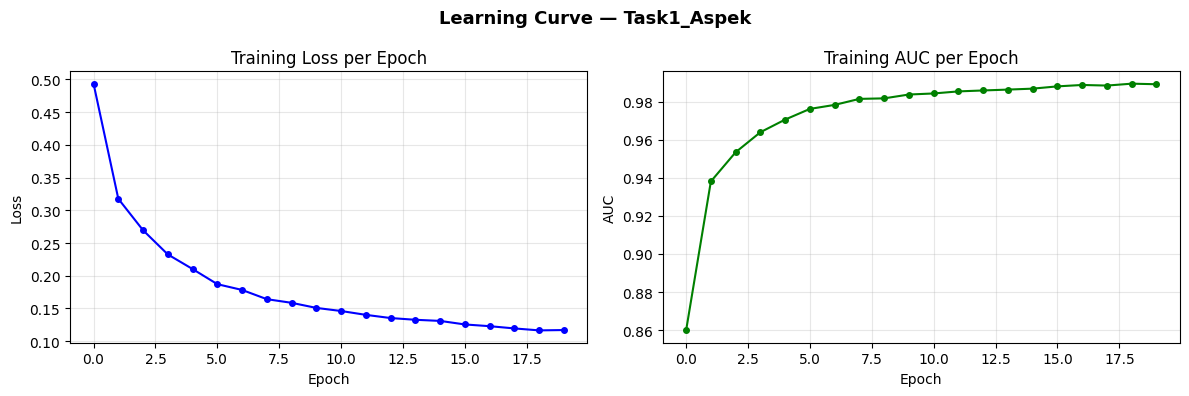


  Selesai! Epoch=20 | Loss=0.1171 | AUC=0.9891 | Waktu=712s
  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final_Fix20/Task1_Aspek/model_final.h5

  Task2_Room
  Skenario  : Skenario4_CNN_FT_Stem
  Arsitektur: CNN | Embedding: FastText

  [1] Load tokenizer...
  [2] Load embedding model dan buat embedding matrix...
       Jenis: FastText
  Vocab: 3,814 | OOV: 0 (0.0%)
  [3] Siapkan data train...
  Jumlah data: 3,066
  Shape X: (3066, 100) | Shape y: (3066, 1)
  [4] Bangun model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │    381,400 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 98, 100)   │     30,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 97, 100)   │     40,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 96, 100)   │     50,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 300)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     19,264 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 521,029 (1.99 MB)

 Trainable params: 139,629 (545.43 KB)

...

96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9860 - auc: 0.9982 - loss: 0.1424
Epoch 14/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9919 - auc: 0.9995 - loss: 0.1199

96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9915 - auc: 0.9990 - loss: 0.1236
Epoch 15/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9896 - auc: 0.9984 - loss: 0.1187

96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9876 - auc: 0.9989 - loss: 0.1193
Epoch 16/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9921 - auc: 0.9991 - loss: 0.1127

96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9912 - auc: 0.9994 - loss: 0.1103
Epoch 17/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9883 - auc: 0.9988 - loss: 0.1146
Epoch 18/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9915 - auc: 0.9989 - loss: 0.1029

96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9912 - auc: 0.9990 - loss: 0.1041
Epoch 19/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9863 - auc: 0.9982 - loss: 0.1159
Epoch 20/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9883 - auc: 0.9976 - loss: 0.1150
Restoring model weights from the end of the best epoch: 18.


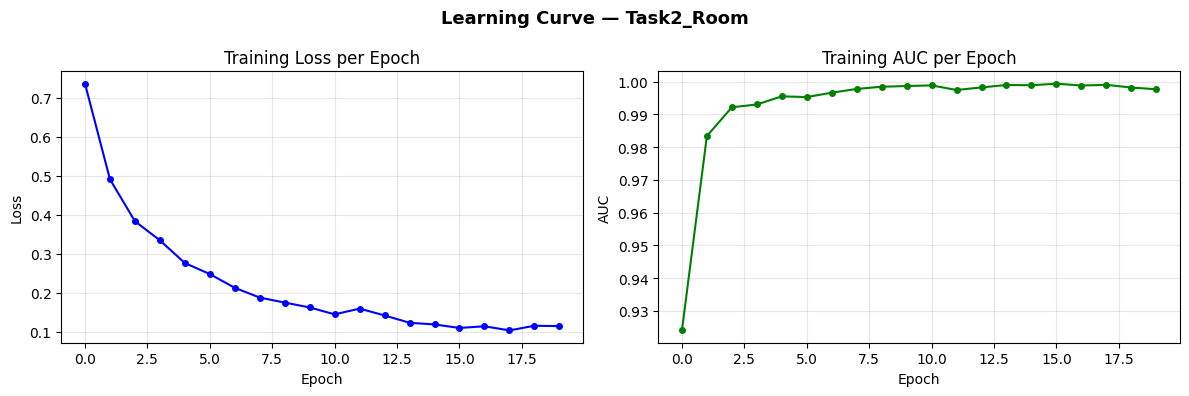


  Selesai! Epoch=20 | Loss=0.1150 | AUC=0.9976 | Waktu=77s
  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final_Fix20/Task2_Room/model_final.h5

  Task3_Hotel
  Skenario  : Skenario5_BiLSTM_W2V_NonStem
  Arsitektur: BILSTM | Embedding: Word2Vec

  [1] Load tokenizer...
  [2] Load embedding model dan buat embedding matrix...
       Jenis: Word2Vec
  Vocab: 5,556 | OOV: 2156 (38.8%)
  [3] Siapkan data train...
  Jumlah data: 2,953
  Shape X: (2953, 100) | Shape y: (2953, 1)
  [4] Bangun model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 100)       │       555,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,401 (2.47 MB)

 Trainable params: 92,801 (362.50 KB)

...

93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - accuracy: 0.9624 - auc: 0.9879 - loss: 0.1311
Epoch 15/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9655 - auc: 0.9910 - loss: 0.1181

93/93 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.9661 - auc: 0.9908 - loss: 0.1179
Epoch 16/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9718 - auc: 0.9917 - loss: 0.1121

93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.9692 - auc: 0.9923 - loss: 0.1081
Epoch 17/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.9705 - auc: 0.9922 - loss: 0.1082
Epoch 18/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9756 - auc: 0.9920 - loss: 0.1029

93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.9739 - auc: 0.9926 - loss: 0.0997
Epoch 19/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.9719 - auc: 0.9917 - loss: 0.1017
Epoch 20/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9757 - auc: 0.9946 - loss: 0.0913

93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.9780 - auc: 0.9943 - loss: 0.0880
Restoring model weights from the end of the best epoch: 20.


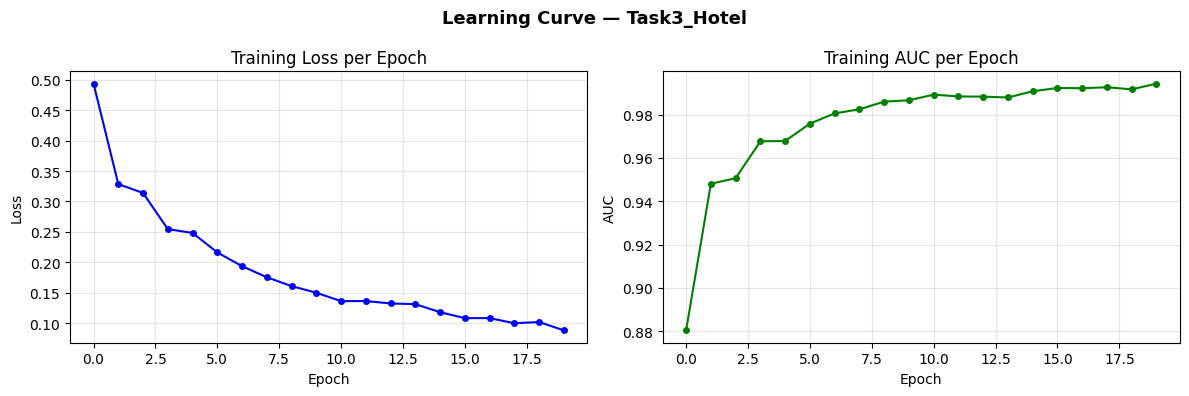


  Selesai! Epoch=20 | Loss=0.0880 | AUC=0.9943 | Waktu=384s
  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final_Fix20/Task3_Hotel/model_final.h5

  Task4_Location
  Skenario  : Skenario1_CNN_W2V_NonStem
  Arsitektur: CNN | Embedding: Word2Vec

  [1] Load tokenizer...
  [2] Load embedding model dan buat embedding matrix...
       Jenis: Word2Vec
  Vocab: 5,556 | OOV: 2156 (38.8%)
  [3] Siapkan data train...
  Jumlah data: 2,378
  Shape X: (2378, 100) | Shape y: (2378, 1)
  [4] Bangun model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │    555,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 98, 100)   │     30,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 97, 100)   │     40,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 96, 100)   │     50,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 300)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     19,264 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 695,229 (2.65 MB)

 Trainable params: 139,629 (545.43 KB)

...

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9912 - auc: 0.9984 - loss: 0.1428
Epoch 13/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9857 - auc: 0.9978 - loss: 0.1475
Epoch 14/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9853 - auc: 0.9983 - loss: 0.1456
Epoch 15/20
74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9869 - auc: 0.9956 - loss: 0.1429

75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9882 - auc: 0.9970 - loss: 0.1366
Epoch 16/20
73/75 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9936 - auc: 0.9986 - loss: 0.1224

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9920 - auc: 0.9983 - loss: 0.1244
Epoch 17/20
73/75 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9944 - auc: 0.9998 - loss: 0.1122

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9929 - auc: 0.9994 - loss: 0.1148
Epoch 18/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9865 - auc: 0.9976 - loss: 0.1284
Epoch 19/20
73/75 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9931 - auc: 0.9984 - loss: 0.1089

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9937 - auc: 0.9977 - loss: 0.1085
Epoch 20/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9886 - auc: 0.9986 - loss: 0.1148
Restoring model weights from the end of the best epoch: 19.


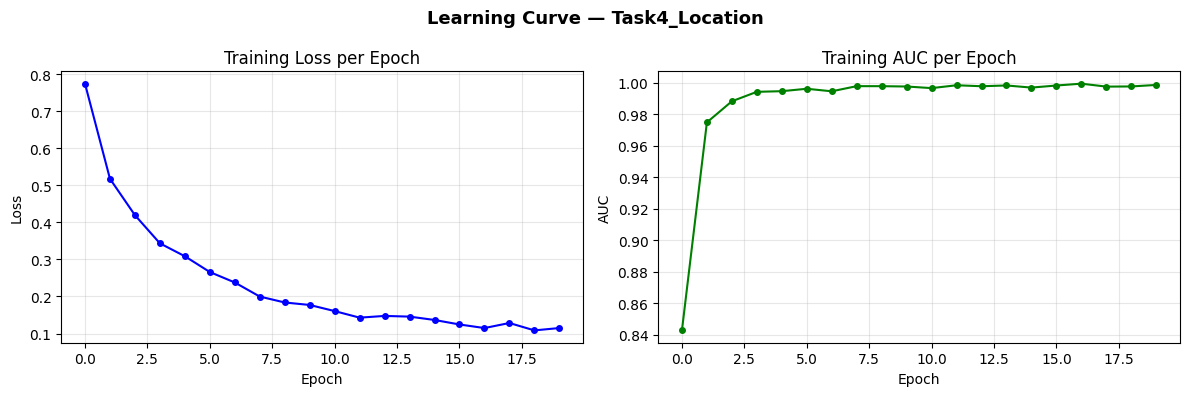


  Selesai! Epoch=20 | Loss=0.1148 | AUC=0.9986 | Waktu=58s
  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final_Fix20/Task4_Location/model_final.h5

  Task5_Service
  Skenario  : Skenario2_CNN_W2V_Stem
  Arsitektur: CNN | Embedding: Word2Vec

  [1] Load tokenizer...
  [2] Load embedding model dan buat embedding matrix...
       Jenis: Word2Vec
  Vocab: 3,814 | OOV: 1351 (35.4%)
  [3] Siapkan data train...
  Jumlah data: 2,500
  Shape X: (2500, 100) | Shape y: (2500, 1)
  [4] Bangun model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │    381,400 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 98, 100)   │     30,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 97, 100)   │     40,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 96, 100)   │     50,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 300)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     19,264 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 521,029 (1.99 MB)

 Trainable params: 139,629 (545.43 KB)

...

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9932 - auc: 0.9990 - loss: 0.1029
Epoch 17/20
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9938 - auc: 0.9998 - loss: 0.0973

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9960 - auc: 0.9998 - loss: 0.0928
Epoch 18/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9947 - auc: 0.9999 - loss: 0.0844

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9960 - auc: 1.0000 - loss: 0.0816
Epoch 19/20
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9968 - auc: 0.9999 - loss: 0.0766

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9960 - auc: 0.9999 - loss: 0.0773
Epoch 20/20
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9956 - auc: 0.9999 - loss: 0.0746

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9964 - auc: 0.9999 - loss: 0.0750
Restoring model weights from the end of the best epoch: 20.


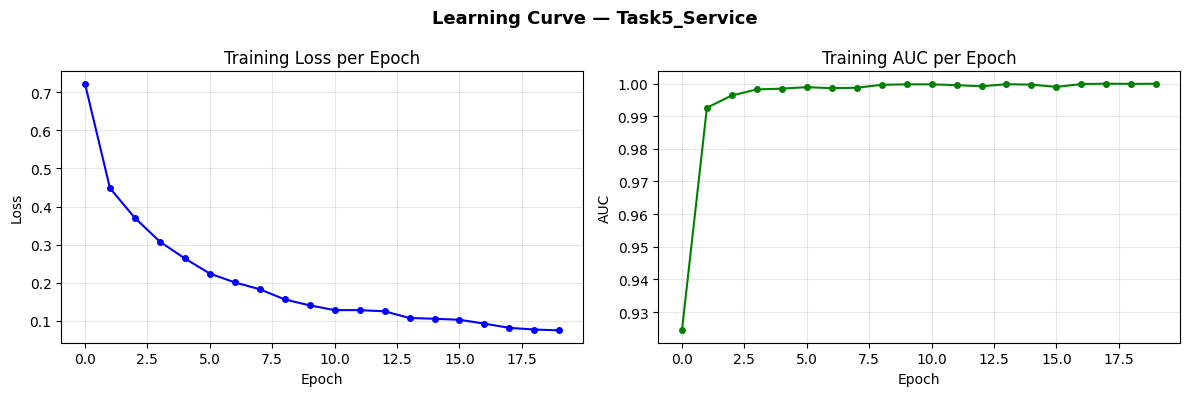


  Selesai! Epoch=20 | Loss=0.0750 | AUC=0.9999 | Waktu=54s
  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final_Fix20/Task5_Service/model_final.h5

  SEMUA RETRAINING SELESAI


In [ ]:
# ============================================================
# Proses retraining untuk semua task.
# Setiap task:
#   1. Load tokenizer → ubah kata ke angka
#   2. Load Word2Vec → buat embedding matrix
#   3. Siapkan X (token) dan y (label)
#   4. Bangun model sesuai arsitektur terbaik
#   5. Training dengan semua data train
#   6. Simpan model terbaik ke .h5
#   7. Simpan history dan grafik
# ============================================================

rekap = []

for task_name, cfg in TASKS.items():

    print(f'\n{"="*60}')
    print(f'  {task_name}')
    print(f'  Skenario  : {cfg["skenario"]}')
    print(f'  Arsitektur: {cfg["arsitektur"].upper()} | '
          f'Embedding: {"FastText" if "fasttext_" in cfg["embed_file"] else "Word2Vec"}')
    print(f'{"="*60}')

    out_dir = cfg['output_dir']

    # Step 1: Load tokenizer
    print('\n  [1] Load tokenizer...')
    with open(cfg['token_file'], 'rb') as f:
        tokenizer = pickle.load(f)

    # Step 2: Load Word Embedding dan buat embedding matrix
    # Deteksi otomatis Word2Vec atau FastText dari nama file
    print('  [2] Load embedding model dan buat embedding matrix...')
    # Gunakan .lower() agar pengecekan tidak sensitif huruf besar/kecil
    nama_file_kecil = cfg['embed_file'].lower()
    if 'fasttext' in nama_file_kecil or 'ft' in nama_file_kecil:
        from gensim.models import FastText
        embed_model = FastText.load(cfg['embed_file'])
        print('       Jenis: FastText')
        jenis_embed = 'FastText'
    else:
        from gensim.models import Word2Vec
        embed_model = Word2Vec.load(cfg['embed_file'])
        print('       Jenis: Word2Vec')
        jenis_embed = 'Word2Vec'

    embedding_matrix = buat_embedding_matrix(embed_model, tokenizer)


    # Step 3: Siapkan data train
    print('  [3] Siapkan data train...')
    X_train, y_train = siapkan_data(
        cfg['train_file'], cfg['text_col'],
        cfg['label_cols'], tokenizer
    )
    jumlah_label = len(cfg['label_cols'])

    # Step 4: Bangun model
    print('  [4] Bangun model...')
    tf.keras.backend.clear_session()
    if cfg['arsitektur'] == 'cnn':
        model = bangun_model_cnn(
            embedding_matrix, MAX_LENGTH, jumlah_label)
    else:
        model = bangun_model_bilstm(
            embedding_matrix, MAX_LENGTH, jumlah_label)
    model.summary()

    # Step 5: Training
    # ModelCheckpoint: simpan model saat train_loss terbaik
    # EarlyStopping: berhenti jika loss tidak turun
    #   selama PATIENCE epoch (sama dengan K-Fold)
    print(f'  [5] Training...')
    model_path = out_dir + 'model_final.h5'

    callbacks = [
        ModelCheckpoint(
            model_path,
            monitor='loss',        # pantau training loss
            save_best_only=True,   # simpan hanya yang terbaik
            verbose=0
        ),
        EarlyStopping(
            monitor='loss',
            patience=PATIENCE,     # patience=2 sama dengan K-Fold
            restore_best_weights=True,
            verbose=1
        ),
    ]

    t_start = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=MAX_EPOCH,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    t_total  = time.time() - t_start
    n_epoch  = len(history.history['loss'])
    fin_loss = history.history['loss'][-1]
    fin_auc  = history.history['auc'][-1]

    # Step 6: Simpan history ke CSV
    df_hist = pd.DataFrame(history.history)
    df_hist.index.name = 'epoch'
    df_hist.to_csv(out_dir + 'history_retraining.csv')

    # Step 7: Tampilkan grafik learning curve
    plot_learning_curve(
        history, task_name,
        out_dir + 'learning_curve_final.png'
    )

    rekap.append({
        'task'      : task_name,
        'arsitektur': cfg['arsitektur'].upper(),
        'n_data'    : len(y_train),
        'n_epoch'   : n_epoch,
        'train_loss': round(fin_loss, 4),
        'train_auc' : round(fin_auc, 4),
        'waktu_detik': round(t_total, 1),
    })

    print(f'\n  Selesai! Epoch={n_epoch} | '
          f'Loss={fin_loss:.4f} | '
          f'AUC={fin_auc:.4f} | '
          f'Waktu={t_total:.0f}s')
    print(f'  Model disimpan: {model_path}')

print(f'\n{"="*60}')
print('  SEMUA RETRAINING SELESAI')
print(f'{"="*60}')

## 6. Rekap dan Simpan ke Excel


In [ ]:
# Tampilkan dan simpan rekap hasil retraining.
# Yang dicatat: epoch berhenti, train loss,
# train AUC, dan waktu training.
# Metrik performa (F1, precision, recall)
# dihitung di notebook evaluasi test.

df_rekap = pd.DataFrame(rekap)
print(df_rekap.to_string(index=False))

excel_path = FINAL_DIR + 'rekap_retraining_final.xlsx'
df_rekap.to_excel(excel_path, index=False)
print(f'\nRekap disimpan: {excel_path}')

# Tampilkan daftar file output
print('\nFile output per task:')
for task_name, cfg in TASKS.items():
    print(f'\n  {task_name}:')
    for fname in sorted(os.listdir(cfg['output_dir'])):
        fpath = os.path.join(cfg['output_dir'], fname)
        kb    = os.path.getsize(fpath) / 1024
        print(f'    {fname} ({kb:.0f} KB)')


          task arsitektur  n_data  n_epoch  train_loss  train_auc  waktu_detik
   Task1_Aspek     BILSTM    7026       20      0.1171     0.9891        711.7
    Task2_Room        CNN    3066       20      0.1150     0.9976         76.7
   Task3_Hotel     BILSTM    2953       20      0.0880     0.9943        383.9
Task4_Location        CNN    2378       20      0.1148     0.9986         58.2
 Task5_Service        CNN    2500       20      0.0750     0.9999         53.8

Rekap disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Model_Final_Fix20/rekap_retraining_final.xlsx

File output per task:

  Task1_Aspek:
    history_retraining.csv (1 KB)
    learning_curve_final.png (69 KB)
    model_final.h5 (2625 KB)

  Task2_Room:
    history_retraining.csv (1 KB)
    learning_curve_final.png (66 KB)
    model_final.h5 (3181 KB)

  Task3_Hotel:
    history_retraining.csv (1 KB)
    learning_curve_final.png (69 KB)
    model_final.h5 (3303 KB)

  Task4_Location:
    history_retraining.csv (1 